# Chapter 1: The mechanics of Learning

## numpy matrix and pyTorch tensor

In [ ]:
import numpy as np
from tqdm.autonotebook import tqdm

In [ ]:
# Start with pytorch
import torch

torch_scalar = torch.tensor(5.34)
torch_vector = torch.tensor([1, 2, 3, 4])
torch_matrix = torch.tensor([[1, 2],
                             [3, 4],
                             [5, 6],
                             [7, 8]])

torch_tensor3d = torch.tensor([
    [
        [1, 2, 3],
        [4, 5, 6]
    ],
    [
        [7, 8, 9],
        [10, 11, 12]
    ],
    [
        [13, 14, 15],
        [16, 17, 18]
    ],
    [
        [19, 20, 21],
        [22, 23, 24]
    ]])

print(f'Example of a scalar tensor: {torch_scalar}')
print(f'Example of a vector tensor: {torch_vector}')
print(f'Example of a matrix tensor: {torch_matrix}')
print(f'Example of a 3D tensor:\n {torch_tensor3d}')

In [3]:
# Explore the shapes of the tensors:

print('Shape of the tensors:\n')
print(torch_scalar.shape)
print(torch_vector.shape)
print(torch_matrix.shape)
print(torch_tensor3d.shape)

Shape of the tensors:

torch.Size([])
torch.Size([4])
torch.Size([4, 2])
torch.Size([4, 2, 3])


In [4]:
# Convert a numpy tensor in to a PyTorch tensor

import numpy as np

x_np = np.random.random((4,4))
print(f'numpy matrix: \n {x_np}')
print(f'Shape of numpy matrix: {x_np.shape}')
print(f'dtype of numpy matrix: {x_np.dtype}')

x_pt = torch.tensor(x_np)
print (f'\nPyTorch tensor: \n{x_pt}')
print(f'Shape of pytorch tensor: {x_pt.shape}')
print(f'dtype of pytorch tensor: {x_pt.dtype}')



numpy matrix: 
 [[0.02792442 0.98866574 0.99918701 0.72773079]
 [0.7438662  0.72565596 0.44462579 0.23260177]
 [0.66827313 0.84606294 0.92407101 0.40511593]
 [0.19969717 0.71316994 0.17390046 0.77500644]]
Shape of numpy matrix: (4, 4)
dtype of numpy matrix: float64

PyTorch tensor: 
tensor([[0.0279, 0.9887, 0.9992, 0.7277],
        [0.7439, 0.7257, 0.4446, 0.2326],
        [0.6683, 0.8461, 0.9241, 0.4051],
        [0.1997, 0.7132, 0.1739, 0.7750]], dtype=torch.float64)
Shape of pytorch tensor: torch.Size([4, 4])
dtype of pytorch tensor: torch.float64


In [5]:
# convert numpy ndarray float64 to float32
x_np = np.asarray(x_np, dtype=np.float32)
x_pt = torch.tensor(x_np, dtype=torch.float32)
print(f'dtype of numpy matrix: {x_np.dtype}')
print(f'dtype of pytorch tensor: {x_pt.dtype}')

dtype of numpy matrix: float32
dtype of pytorch tensor: torch.float32


In [6]:
# Use of boolean tensors for binary masks
b_np = (x_np > 0.5)
print(b_np)
print(b_np.dtype)

b_pt = (x_pt > 0.5)
print("\n",b_pt)
print(b_pt.dtype)

[[False  True  True  True]
 [ True  True False False]
 [ True  True  True False]
 [False  True False  True]]
bool

 tensor([[False,  True,  True,  True],
        [ True,  True, False, False],
        [ True,  True,  True, False],
        [False,  True, False,  True]])
torch.bool


In [7]:
# Similarities between numpy matrix and pytorch tensor
print(np.sum(x_np))
print(torch.sum(x_pt))

9.595554
tensor(9.5956)


In [8]:
# transpose elements
print('numpy\n',np.transpose(x_np))
print('\n',x_np.T)
print('\ntorch\n', torch.transpose(x_pt, 0, 1))

numpy
 [[0.02792441 0.7438662  0.66827315 0.19969717]
 [0.98866576 0.725656   0.84606296 0.71316993]
 [0.999187   0.4446258  0.924071   0.17390046]
 [0.7277308  0.23260178 0.40511593 0.7750064 ]]

 [[0.02792441 0.7438662  0.66827315 0.19969717]
 [0.98866576 0.725656   0.84606296 0.71316993]
 [0.999187   0.4446258  0.924071   0.17390046]
 [0.7277308  0.23260178 0.40511593 0.7750064 ]]

torch
 tensor([[0.0279, 0.7439, 0.6683, 0.1997],
        [0.9887, 0.7257, 0.8461, 0.7132],
        [0.9992, 0.4446, 0.9241, 0.1739],
        [0.7277, 0.2326, 0.4051, 0.7750]])


In [14]:
import timeit
x = torch.rand(2**11, 2**11)
time_cpu = timeit.timeit('x_timeit@x_timeit', globals=globals(), number=100)
print(f'CPU processing time: {time_cpu}')

CPU processing time: 6.0720204720000766


In [15]:
# verify if we have an NVIDIA GPU available
print('is CUDA available? :', torch.cuda.is_available())
device = torch.device('cuda')

is CUDA available? : True


In [16]:
x = x.to(device)
time_gpu = timeit.timeit('x_timeit@x_timeit', globals=globals(), number=100)
print (f'GPU processing time:{time_gpu}')

GPU processing time:5.353613785999869


## Automatic differenciation with pyTorch

In [18]:
# Call dependencies
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# define the function f(x) = (x - 2)**2
def f(x):
    return torch.pow((x-2), 2)

<Axes: >

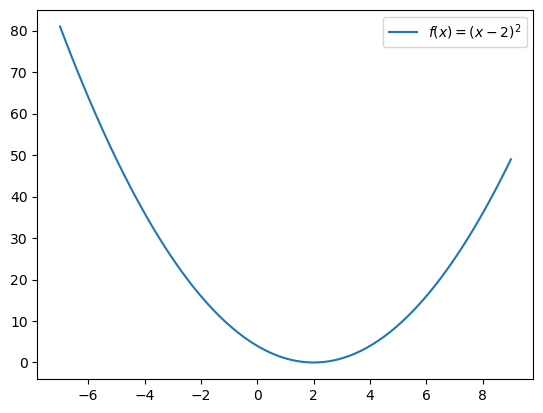

In [20]:
# Plot the function
x_axis_vals = np.linspace(-7, 9, 100)
y_axis_vals = f(torch.tensor(x_axis_vals)).numpy()

sns.lineplot(x=x_axis_vals, y=y_axis_vals, label='$f(x) = (x-2)^2$')

In [21]:
# Define the derivative of the fucntion f(x) = (x - 2)**2
def fP(x):
    return 2*x - 4

<Axes: ylabel='None'>

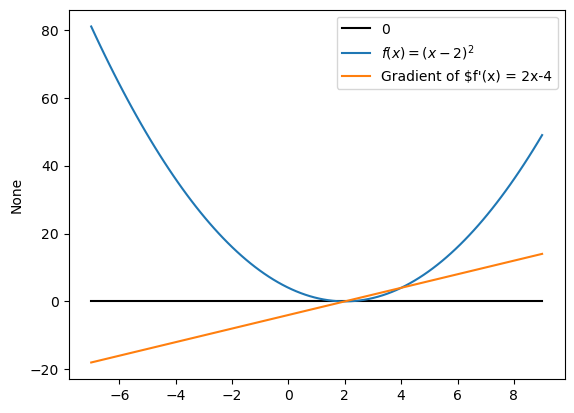

In [22]:
# calculate derivative values and plot
y_axis_p = fP(torch.tensor(x_axis_vals))

sns.lineplot(x=x_axis_vals, y=[0.0]*len(x_axis_vals), label='0', color='black') # horizontal line at y=0
sns.lineplot(x=x_axis_vals, y=y_axis_vals, label='$f(x) = (x-2)^2$') # Plot of the equation
sns.lineplot(x=x_axis_vals, y=y_axis_p, label="Gradient of $f'(x) = 2x-4")


In [23]:
# Use automatic differentiation of pyTorch
x = torch.tensor([-3.5], requires_grad=True)
print(x)
print(x.grad)

tensor([-3.5000], requires_grad=True)
None


In [24]:
# compute f(x)
value = f(x)
print(value)

tensor([30.2500], grad_fn=<PowBackward0>)


In [25]:
value.backward()
print(x.grad)

tensor([-11.])


In [26]:
# All things together. Define initial parameters
x1 = torch.tensor([-5.5], requires_grad=True) # starting guess
x_cur = x1.clone() # clone the starting guess to point to other object, not x1
x_prev = x_cur*100 # previous value to work with
epsilon = 1e-5 # limit of error to stop iterating
eta = 0.1 # learning rate

In [27]:
# create the loop
while torch.linalg.norm(x_cur - x_prev) > epsilon:
    x_prev = x_cur.clone()
    # compute function, gradient and update values
    value = f(x1)
    value.backward()
    x1.data -= eta * x1.grad

    x1.grad.zero_() # delete zeros
    x_cur = x1.data 

print(x_cur)

tensor([2.0000])


## Optimizers and parameters in pyTorch

In [28]:
import torch.nn as nn

In [29]:
# Create a object for paramters
x_param = torch.nn.Parameter(torch.tensor([-5.0]), requires_grad=True)

In [30]:
# Create an optimizer using SGD "stochastic gradient descent"
optimizer = torch.optim.SGD([x_param], lr=eta)

In [31]:
# Create the backpropagation code
for epoch in range(60):
    optimizer.zero_grad()
    loss_incurred = f(x_param)
    loss_incurred.backward()
    optimizer.step()
print(x_param.data)
print(f(x_param.data))

tensor([2.0000])
tensor([1.1511e-10])


## Loading dataset objects

In [33]:
# Call neccessary dependencies

import pandas as pd
from torch.utils.data import Dataset
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [34]:
# Load dataset with sklearn
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=True) # Add "as_frame" to avoid errors with pandas
print(X.shape)

(70000, 784)


In [35]:
# Create the class and functions
class SimpleDataset(Dataset):
    """
    Create a dataset class that takes in X and y as input. starts with "__init__ method.
    Needs a "__getitem__" method tat returns the data and lable as a tuple(inputs, outputs)
    Also needs the __lenLL function to know the lenght of the datas set
    """
    def __init__(self, X, y):
        super(SimpleDataset, self).__init__()
        self.X = X.values
        self.y = y.values

    def __getitem__(self, index):
        inputs = torch.tensor(self.X[index,:], dtype=torch.float32)
        targets = torch.tensor(int(self.y[index]), dtype=torch.int64)
        return inputs, targets

    def __len__(self):
        return self.X.shape[0]

In [36]:
# Create the dataset
dataset = SimpleDataset(X, y)

In [37]:
# Exploere the data set quickly
print(f'Length of dataset: {len(dataset)}')
example, label = dataset[0]
label = label
print(f'Dataset features: {example.shape}')
print(f'Lable of index 0: {label}')

Length of dataset: 70000
Dataset features: torch.Size([784])
Lable of index 0: 5


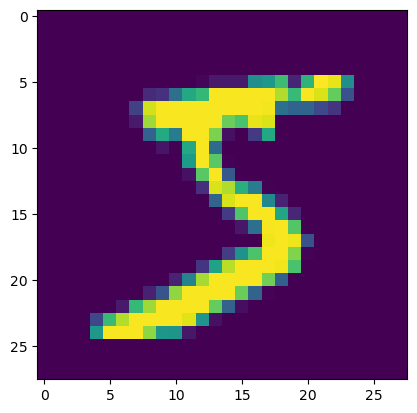

In [38]:
# Confirm that the loader is working by reshaping the data back into an image
plt.imshow(example.reshape((28,28)))

## Spliting the dataset into a "training" set and "testing" set

* Use 80% of data for training and 20% of data for testing.
* Usage of the "random_split" method.

In [39]:
# Spliting the data set
train_size = int(len(dataset)*0.8)
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, (train_size, test_size))

In [40]:
# Verify the split
print(f'{len(train_dataset)} examples for training and {len(test_dataset)} for testing.')

56000 examples for training and 14000 for testing.
